<a href="https://colab.research.google.com/github/GargEngineers7002/linear_regression_from_scratch/blob/main/salary_prediction_using_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
from google.colab import drive
import os

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("kaggle credentials copied")

kaggle credentials copied


In [34]:
!kaggle datasets download -d krishnaraj30/salary-prediction-data-simple-linear-regression

Dataset URL: https://www.kaggle.com/datasets/krishnaraj30/salary-prediction-data-simple-linear-regression
License(s): CC0-1.0
salary-prediction-data-simple-linear-regression.zip: Skipping, found more recently modified local copy (use --force to force download)


In [35]:
!unzip salary-prediction-data-simple-linear-regression.zip -d datasets/

Archive:  salary-prediction-data-simple-linear-regression.zip
replace datasets/Salary Data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: datasets/Salary Data.csv  
replace datasets/Salary_Data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: datasets/Salary_Data.csv  


In [36]:
!ls datasets/

'Salary Data.csv'   Salary_Data.csv


In [37]:
import pandas as pd

df= pd.read_csv("datasets/Salary_Data.csv")
df.head()


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


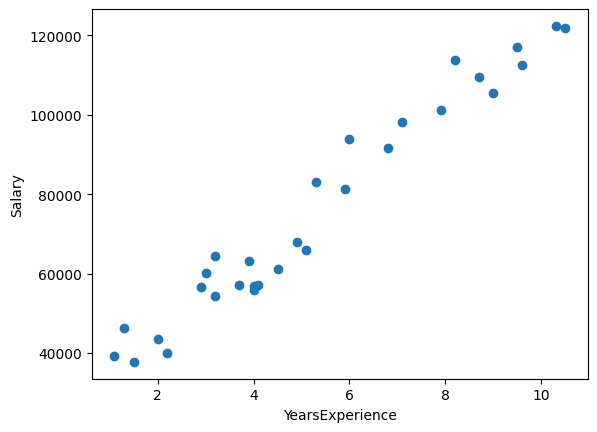

In [38]:
import matplotlib.pyplot as plt
x_train=df["YearsExperience"].values
y_train=df["Salary"].values

plt.scatter(x_train,y_train)
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.show()

In [48]:
def cost_function(x,y,w,b):
  m=len(x)
  cost_sum=0

  for i in range(m):
    f=w*x[i]+b
    cost_sum+=(f-y[i])**2

  total_cost=(1/(2*m))*cost_sum
  return total_cost


In [40]:
def gradient_function(x,y,w,b):
  m=len(x)
  dj_dw=0
  dj_db=0

  for i in range(m):
    f=w*x[i]+b
    dj_dw+=(f-y[i])*x[i]
    dj_db+=(f-y[i])

  return dj_dw/m,dj_db/m

In [46]:
def gradient_descent_function(x,y,w,b,alpha):
  dj_dw,dj_db=gradient_function(x,y,w,b)

  w=w-alpha*dj_dw
  b=b-alpha*dj_db

  return w,b

In [52]:
w=0
b=0
for i in range(10000):
  w,b=gradient_descent_function(x_train,y_train,w,b,0.01)
  if i%1000==0:
    print(f"Iteration {i}: Cost {cost_function(x_train,y_train,w,b)}")

print(f'w: {w} ,b: {b}')

Iteration 0: Cost 1344612525.8413548
Iteration 1000: Cost 16523106.110673292
Iteration 2000: Cost 15648329.194311943
Iteration 3000: Cost 15635661.98387988
Iteration 4000: Cost 15635478.556291511
Iteration 5000: Cost 15635475.900167624
Iteration 6000: Cost 15635475.861705618
Iteration 7000: Cost 15635475.861148665
Iteration 8000: Cost 15635475.861140601
Iteration 9000: Cost 15635475.861140486
w: 9449.962323709777 ,b: 25792.20018347487


In [54]:
def compute_r2(y_true, x, w, b):
    y_pred = w * x + b
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

r2 = compute_r2(y_train, x_train, w, b)
rmse = np.sqrt(2 * cost_function(x_train, y_train, w, b))
print(f'R-squared Score: {r2:.4f}')
print(f'Average Error (RMSE): ${rmse:.2f}')

R-squared Score: 0.9570
Average Error (RMSE): $5592.04


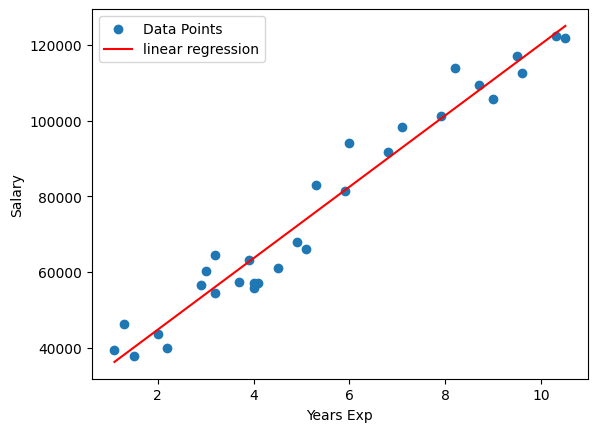

In [43]:
import numpy as np

plt.scatter(x_train,y_train,label='Data Points')
x_vals=np.linspace(min(x_train),max(x_train),100)
y_vals=w*x_vals+b
plt.plot(x_vals,y_vals,color='red',label="linear regression")
plt.xlabel("Years Exp")
plt.ylabel("Salary")
plt.legend()
plt.show()